### ARIMA Estimation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.stats.diagnostic import acorr_ljungbox
import pmdarima as pm

In [2]:
np.random.seed(40)

# 1) simulate ARIMA(p,d,q) models
# ARMA(1,1)
arma_process = ArmaProcess(ar=[1, -0.5], ma=[1, 0.5])
sim_arma = arma_process.generate_sample(nsample=1000)

ARMA(p, q): $(1-\phi_1 L - \cdots -\phi_p L^p)y_t = (1-\theta_1 L -  \cdots - \theta_{q} L^p) \epsilon_t$

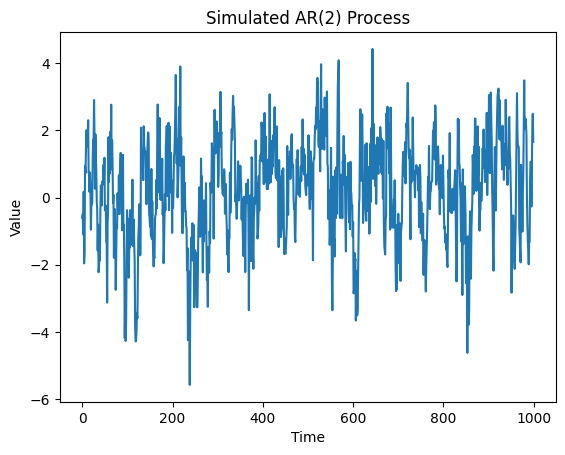

In [3]:
np.random.seed(40)

# Simulate AR(2): phi1=0.6, phi2=0.2
ar_process = ArmaProcess(ar=[1, -0.6, -0.2], ma=[1])
y = ar_process.generate_sample(nsample=1000)

# Plot
plt.plot(y)
plt.title("Simulated AR(2) Process")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

In [4]:
# 2) estimate ARIMA(p,d,q) models
model1 = sm.tsa.ARIMA(y, order=(2, 0, 0)).fit()
print(model1.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1412.347
Date:                Mon, 23 Feb 2026   AIC                           2832.694
Time:                        16:07:13   BIC                           2852.326
Sample:                             0   HQIC                          2840.156
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2258      0.146      1.546      0.122      -0.061       0.512
ar.L1          0.6261      0.029     21.334      0.000       0.569       0.684
ar.L2          0.1572      0.030      5.183      0.0

In [5]:
# Ljung-Box test on residuals
ljung1 = acorr_ljungbox(model1.resid, lags=[10], return_df=True)
print("\nLjung-Box Test (Correct Spec):")
print(ljung1)


Ljung-Box Test (Correct Spec):
     lb_stat  lb_pvalue
10  5.594383   0.848113


In [6]:
# misspecified case
model2 = sm.tsa.ARIMA(y, order=(0, 0, 2)).fit()
print(model2.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -1506.930
Date:                Mon, 23 Feb 2026   AIC                           3021.859
Time:                        16:07:20   BIC                           3041.490
Sample:                             0   HQIC                          3029.320
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2229      0.070      3.192      0.001       0.086       0.360
ma.L1          0.6168      0.028     22.236      0.000       0.562       0.671
ma.L2          0.3809      0.029     13.018      0.0

In [7]:
ljung2 = acorr_ljungbox(model2.resid, lags=[10], return_df=True)
print("\nLjung-Box Test (Misspecified):")
print(ljung2)


Ljung-Box Test (Misspecified):
       lb_stat     lb_pvalue
10  290.987853  1.247327e-56


In [8]:
# 3) auto.arima 
autofit = pm.auto_arima(y, seasonal=False, d=1, start_p=0, start_q=0, max_p=5, max_q=5, trend='t',
                      method='lbfgs', information_criterion='aicc', stepwise=True, suppress_warnings=True)
print("\nAuto ARIMA result:")
print(autofit.summary())


Auto ARIMA result:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:               SARIMAX(2, 1, 1)   Log Likelihood               -1442.868
Date:                Mon, 23 Feb 2026   AIC                           2895.736
Time:                        16:08:14   BIC                           2920.270
Sample:                             0   HQIC                          2905.061
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
drift       2.777e-06   2.19e-05      0.127      0.899   -4.01e-05    4.57e-05
ar.L1          0.3165      0.159      1.990      0.047       0.005       0.628
ar.L2          0.0577      0.064

### ARMA Forecasting

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error
from arch.__future__ import reindexing
from statsmodels.tsa.arima_process import ArmaProcess

In [10]:
# AR(2)
np.random.seed(40)
ar = np.array([1, -0.6, -0.2])  # AR coefficients
ma = np.array([1])              # MA part is 0

ar2_process = ArmaProcess(ar, ma)
# true DGP: AR(2)
y = ar2_process.generate_sample(nsample=500)

In [11]:
## Rolling window forecasting
w_size = 250
nf = len(y) - w_size # number of forecasts 

AR2_pred = []
MA2_pred = []

for i in range(nf):
    y_window = y[i:i + w_size]
    
    # AR(2) forecast
    model_ar2 = sm.tsa.ARIMA(y_window, order=(2, 0, 0)).fit()
    forecast_ar2 = model_ar2.forecast(steps=1)
    AR2_pred.append(forecast_ar2[0])
    
    # MA(2) forecast
    model_ma2 = sm.tsa.ARIMA(y_window, order=(0, 0, 2)).fit()
    forecast_ma2 = model_ma2.forecast(steps=1)
    MA2_pred.append(forecast_ma2[0])

AR2_pred = np.array(AR2_pred)
MA2_pred = np.array(MA2_pred)

real = y[-nf:]


In [12]:
# Comparison of forecast loss
mse_AR2 = mean_squared_error(real, AR2_pred)
mse_MA2 = mean_squared_error(real, MA2_pred)

mae_AR2 = mean_absolute_error(real, AR2_pred)
mae_MA2 = mean_absolute_error(real, MA2_pred)

print("MSE Comparison:")
print(np.column_stack([mse_AR2, mse_MA2]))

print("MAE Comparison:")
print(np.column_stack([mae_AR2, mae_MA2]))

MSE Comparison:
[[0.79408548 0.95739775]]
MAE Comparison:
[[0.69997344 0.76828554]]


In [13]:
## DMW test
from dieboldmariano import dm_test

dmw_stat, dmw_p = dm_test(real, AR2_pred, MA2_pred, h=1, one_sided =True)

print(f"\nDMW Test Statistic: {dmw_stat:.4f}, p-value: {dmw_p:.4f}")


DMW Test Statistic: -3.2549, p-value: 0.0006


In [14]:
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac, cov_white_simple
from scipy.stats import norm

### GW test
def gw_test(x, y, p, T, tau, method="HAC", alternative="two.sided"):
    x = np.asarray(x).flatten()
    y = np.asarray(y).flatten()
    p = np.asarray(p).flatten()

    if len(x) != len(y):
        raise ValueError("Length of x and y must match.")
    
    if tau < 1:
        raise ValueError("Predictive horizon tau must be >= 1.")

    l1 = np.abs(x - p)
    l2 = np.abs(y - p)
    diff = l1 - l2
    q = len(l1)
    m = T - q
    n = T - tau - m + 1
    delta = np.mean(diff)

    X = np.ones((q, 1))
    model = sm.OLS(diff, X).fit()

    if tau == 1:
        stat = model.tvalues[0]
        method_used = "Standard Statistic Simple Regression Estimator"
    else:
        if method == "HAC":
            cov = cov_hac(model, nlags=tau)
            method_used = "HAC Covariance matrix Estimation"
        elif method == "NeweyWest":
            cov = cov_hac(model, nlags=tau)
            method_used = "Newey-West HAC Covariance matrix Estimation"
        elif method == "Andrews":
            cov = cov_hac(model, nlags=tau, kernel="bartlett")
            method_used = "Kernel-based HAC Covariance matrix Estimation"
        elif method == "LumleyHeagerty":
            cov = cov_white_simple(model)
            method_used = "Lumley HAC Covariance matrix Estimation"
        else:
            raise ValueError("Invalid method selected.")
        se = np.sqrt(cov[0, 0])
        stat = delta / se

    if alternative == "two.sided":
        pval = 2 * norm.cdf(-abs(stat))
    elif alternative == "less":
        pval = norm.cdf(stat)
    elif alternative == "greater":
        pval = norm.sf(stat)
    else:
        raise ValueError("Invalid alternative hypothesis")

    return {
        "statistic": stat,
        "p_value": pval,
        "method": method_used,
        "alternative": alternative
    }

In [15]:
gw_result = gw_test(AR2_pred, MA2_pred, real, T=250, tau=1)

print(f"\nGW Test Statistic: {gw_result['statistic']:.4f}, p-value: {gw_result['p_value']:.4f}")
print(f"Method: {gw_result['method']}")
print(f"Alternative Hypothesis: {gw_result['alternative']}")


GW Test Statistic: -2.7846, p-value: 0.0054
Method: Standard Statistic Simple Regression Estimator
Alternative Hypothesis: two.sided


### Unit root test

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

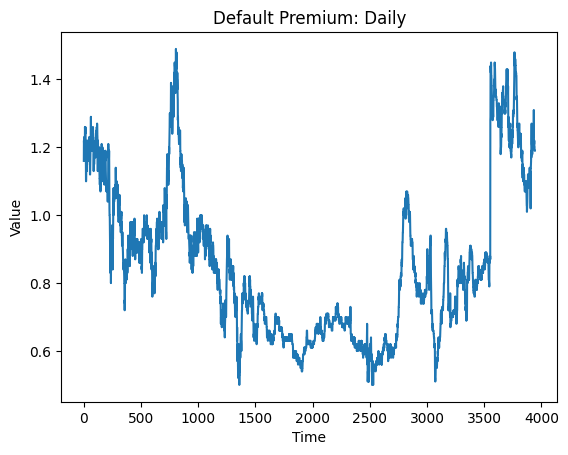

In [17]:
data = pd.read_excel("DefaultPremium_data.xls")

daily = data['Daily'].dropna().to_numpy()

plt.plot(daily)
plt.title("Default Premium: Daily")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

In [18]:
# AR(1) without trend
X1 = sm.add_constant(daily[:-1])
model_ar1 = ARIMA(daily, order=(1, 0, 0))
result_ar1 = model_ar1.fit()
print(result_ar1.summary())

# AR(1) with linear trend (xreg = time)
exog = np.arange(len(daily))
model_ar1t = ARIMA(daily, order=(1, 0, 0), exog=exog)
result_ar1t = model_ar1t.fit()
print(result_ar1t.summary())

c:\Users\A\anaconda3\envs\ts_analysis\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3942
Model:                 ARIMA(1, 0, 0)   Log Likelihood                9786.308
Date:                Mon, 23 Feb 2026   AIC                         -19566.615
Time:                        16:09:04   BIC                         -19547.777
Sample:                             0   HQIC                        -19559.932
                               - 3942                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8557      0.087      9.801      0.000       0.685       1.027
ar.L1          0.9961      0.002    663.980      0.000       0.993       0.999
sigma2         0.0004   1.96e-06    208.272      0.0

In [19]:
## Augmented Dickey-Fuller (ADF) Test, 
#  ADF with intercept only
adf_result1 = adfuller(daily, regression='c')  # c = constant only
print("ADF (intercept):")
print(f"Test statistic: {adf_result1[0]}")
print(f"p-value: {adf_result1[1]}")
print(f"Critical values: {adf_result1[4]}")

# ADF with trend and intercept
adf_result2 = adfuller(daily, regression='ct')  # ct = constant + trend
print("\nADF (intercept + trend):")
print(f"Test statistic: {adf_result2[0]}")
print(f"p-value: {adf_result2[1]}")
print(f"Critical values: {adf_result2[4]}")

ADF (intercept):
Test statistic: -2.608091883108759
p-value: 0.09133634627879356
Critical values: {'1%': np.float64(-3.4320112253382087), '5%': np.float64(-2.8622740384546113), '10%': np.float64(-2.5671607370208576)}

ADF (intercept + trend):
Test statistic: -2.5301721440848666
p-value: 0.3130450939495534
Critical values: {'1%': np.float64(-3.9610701588490884), '5%': np.float64(-3.411605180733088), '10%': np.float64(-3.127706663591827)}


Numerically different results between R and Python: Diffrence in default lag length
- Python: AIC
- R: calculated as $k = \text{trunc}((n-1)^{1/3})$
- Using the following, one is able to replicate R (almost same)
```
n = len(x)
r_style_lags = int(np.trunc((n - 1)**(1/3)))

result = adfuller(x, maxlag=r_style_lags, regression='ct', autolag=None)
```

In [20]:
n = len(daily)
r_style_lags = round(np.trunc((n - 1)**(1/3)))

adf_result1 = adfuller(daily, regression='c', maxlag=r_style_lags, autolag=None)  # c = constant only
print("ADF (intercept):")
print(f"Test statistic: {adf_result1[0]}")
print(f"p-value: {adf_result1[1]}")
print(f"Critical values: {adf_result1[4]}")

# ADF with trend and intercept
adf_result2 = adfuller(daily, regression='ct', maxlag=r_style_lags, autolag=None)  # ct = constant + trend
print("\nADF (intercept + trend):")
print(f"Test statistic: {adf_result2[0]}")
print(f"p-value: {adf_result2[1]}")
print(f"Critical values: {adf_result2[4]}")

ADF (intercept):
Test statistic: -2.507523844063542
p-value: 0.11365440832561208
Critical values: {'1%': np.float64(-3.432016729687226), '5%': np.float64(-2.862276469956464), '10%': np.float64(-2.567162031453515)}

ADF (intercept + trend):
Test statistic: -2.4176404649461434
p-value: 0.37028335575962035
Critical values: {'1%': np.float64(-3.9610777813707245), '5%': np.float64(-3.4116088753242493), '10%': np.float64(-3.1277088388174388)}


In [21]:
# KPSS with intercept only
kpss_result1 = kpss(daily, regression='c', nlags='legacy')
print("\nKPSS (intercept):")
print(f"Test statistic: {kpss_result1[0]}")
print(f"p-value: {kpss_result1[1]}")
print(f"Critical values: {kpss_result1[3]}")

# KPSS with trend
kpss_result2 = kpss(daily, regression='ct', nlags='legacy')
print("\nKPSS (intercept + trend):")
print(f"Test statistic: {kpss_result2[0]}")
print(f"p-value: {kpss_result2[1]}")
print(f"Critical values: {kpss_result2[3]}")


KPSS (intercept):
Test statistic: 2.1782238320776726
p-value: 0.01
Critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}

KPSS (intercept + trend):
Test statistic: 2.0468283039554214
p-value: 0.01
Critical values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}


C:\Users\A\AppData\Local\Temp\ipykernel_26428\1694912253.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result1 = kpss(daily, regression='c', nlags='legacy')
C:\Users\A\AppData\Local\Temp\ipykernel_26428\1694912253.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result2 = kpss(daily, regression='ct', nlags='legacy')


In [22]:
## PP test
pp_result = PhillipsPerron(daily)
print("\nPP Test")
print(f"Test statistic: {pp_result.stat}")
print(f"p-value: {pp_result.pvalue}")


PP Test
Test statistic: -2.504676739278188
p-value: 0.11434056643180773
